#Regressão Linear Simples

Modelos de regressão (lineares e não lineares) são usados para prever um valor real, como salário, por exemplo. Se sua variável independente for o tempo, você está prevendo valores futuros, caso contrário, seu modelo está prevendo valores presentes, mas desconhecidos. As técnicas de regressão variam de Regressão Linear a Random Forests Regression.


y = b0 + b1*x + e

Em que:

- y - variável dependente -> target, resposta
- x - variável independente -> feature, entrada
- b0 - ponto de cruzamento da curva com o eixo y.
- b1 - coeficiente de variação de y dependente de x. Determina o quão inclinada a reta será.
- e - erro de previsão (y_real - y_previsto)


##Hipóteses

- Variância homogênea (ordem do erro não se altera nos domínios)
- Observações independentes (não há repetição de x)
- Relação linear

##Descrição em Python com exemplo

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split



In [52]:
path = 'https://raw.githubusercontent.com/OrlandoIFPR/ml2/refs/heads/main/Dataframes/'

In [53]:
dataset = pd.read_csv(path+ 'melb_data.csv')

In [54]:
dataset.head()

,Unnamed: 0,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,5,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,6,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [55]:
dataset.columns

Index(['Unnamed: 0', 'Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method',
       'SellerG', 'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom',
       'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea',
       'Lattitude', 'Longtitude', 'Regionname', 'Propertycount'],
      dtype='object')

In [56]:
dataset.shape

(18396, 22)

In [76]:
dataset = dataset.dropna(axis=0) #retira as linhas com NaN

features = ['YearBuilt']

#features = ['BuildingArea']

X = dataset[features]


X.describe()


,YearBuilt
count,6196.000000
mean,1964.081988
std,38.105673
min,1196.000000
25%,1940.000000
50%,1970.000000
75%,2000.000000
max,2018.000000


In [58]:
y = dataset.Price
y.describe()

,Price
count,6.196000e+03
mean,1.068828e+06
std,6.751564e+05
min,1.310000e+05
25%,6.200000e+05
50%,8.800000e+05
75%,1.325000e+06
max,9.000000e+06


In [59]:
y.head()

,Price
1,1035000.0
2,1465000.0
4,1600000.0
6,1876000.0
7,1636000.0


In [70]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/3, random_state = 1)

In [71]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)

E se eu quiser realizar uma predição para uma linha específica do meu test_set?

In [66]:
print(regressor.predict([ [10] ] )); # entre [[]] por ser um array 2D

[579644.32]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


E para descobrirmos a reta definida pela regressão?

In [67]:
print(regressor.coef_) #B1
print(regressor.intercept_) #B0


[3711.82]
542526.1161875474


##Métodos de validação do modelo

Como sabemos se a nossa predição é boa?

Precisamos utilizar métricas de avaliação para o nosso modelo.
Para casos de classificação, podemos usar a acurácia, pois o que precisamos saber não é a distância do erro, mas sim a porcentagem acertada.

Para casos de predição, como os que vamos ver nas próximas aulas, precisamos saber quão grande é o erro comparativamente com o valor correto do target, dentro do nosso universo de teste.

**Coeficiente de determinação R²**

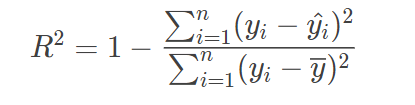

em que
- n é o número de medições
- y_i é o valor da iésima observação no conjunto de dados de validação
- y_barra é o valor médio do conjunto de dados de validação
- y^ é o valor previsto para a iésima observação.

A fração é a razão entre a soma dos quadrados dos resíduos e a soma dos quadrados dos dados totais. Os resíduos representam a diferença entre a previsão e a realidade. Quanto mais próximo R2 estiver de 1, melhor será a previsão. Alguns pontos muito bons podem trazer o coeficiente para próximo de 1, parecendo que sua previsão é muito boa.

In [72]:
from sklearn.metrics import r2_score

r2_score(y_test, y_pred)


0.2726717364231651

**MAE - Mean Absolute Error**

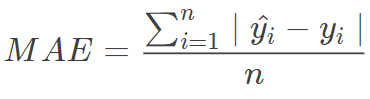

em que
- n é o número de medições
- y_i é o valor da iésima observação no conjunto de dados de validação
- y^ é o valor previsto para a iésima observação.

Quanto menor o MAE (mais próximo de 0), melhor a previsão. Este indicador não leva em conta a variabilidade das previsões. De fato, se os valores previstos forem ao mesmo tempo em grande parte superestimados e subestimados, o MAE ainda pode ser relativamente baixo.




In [73]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(y_test, y_pred)

# Significa que em média o preço teve uma diferença de 378.557,83

387227.95747011824

**RMSE - Root Mean Square Error**

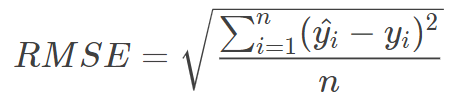

em que
- n é o número de medições
- y_i é o valor da iésima observação no conjunto de dados de validação
- y^ é o valor previsto para a iésima observação.

Quanto menor o RMSE (mais próximo de 0), melhor a previsão. Este indicador não leva em conta a variabilidade das previsões.

In [ ]:
from sklearn.metrics import mean_squared_error

mean_squared_error(y_test, y_pred)

MSE = mean_squared_error(y_test, y_pred)/len(y_test)
MSE

160448388.32937998

In [74]:
from sklearn.metrics import root_mean_squared_error


RMSE = root_mean_squared_error(y_test, y_pred)
RMSE

579909.0515913754

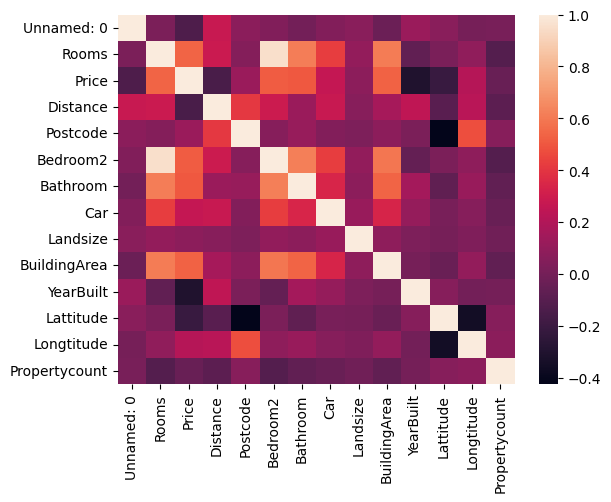

In [75]:
corr = dataset.corr(numeric_only=True)
sns.heatmap(corr);

#Regressão Linear **Múltipla**

Usado quando temos duas ou mais variáveis de features para prever um target.

Assume as mesmas hipóteses da regressão linear simples, com as mesmas respostas.

Cuidado com as features! Se duas forem altamente correlacionadas, utilizar apenas uma, ou você pode ter problemas na sua regressão -> cria um bias para minimizar este erro ao invés de achar o menor erro geral (importância da EDA!).

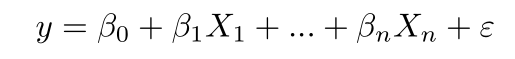

em que:

- y = o valor previsto da variável dependente
- b0 = a interceptação y
- b1 = o coeficiente de regressão (b1) da primeira variável independente (X1)
- … = faça o mesmo para quantas variáveis ​​independentes você estiver testando
- bn = o coeficiente de regressão da última variável independente
e = erro do modelo

Geometricamente, isso é semelhante a ajustar um plano a pontos em três dimensões ou ajustar um hiperplano a pontos em dimensões superiores.

A natureza multidimensional de tais regressões as torna mais difíceis de visualizar.

In [88]:
dataset = dataset.dropna(axis=0) #retira as linhas com NaN

features = ['Rooms', 'Distance', 'Postcode', 'Bedroom2',
            'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Propertycount']

features = ['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'BuildingArea',
            'YearBuilt', 'Propertycount']

#features = ['Rooms', 'Bathroom', 'Car', 'Landsize', 'Distance', 'BuildingArea']

#features = ['Distance', 'BuildingArea','YearBuilt','Postcode']

X = dataset[features]
y = dataset.Price

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/3, random_state = 0)

regressor2 = LinearRegression()
regressor2.fit(X_train, y_train)

y_pred = regressor2.predict(X_test)


In [93]:
print(regressor2.coef_) #B1 até Bn
print(regressor2.intercept_) #B0

[ 1.28e+05 -2.73e+04  2.54e+05  5.16e+04  1.09e+01  2.24e+03 -5.34e+03
  8.64e-01]
10630370.130455732


In [89]:
r2_score(y_test, y_pred)

0.4963056885880398

In [90]:
r2_score(y_test, y_pred)

0.4963056885880398

In [91]:
mean_absolute_error(y_test, y_pred)

304091.5136336311

In [ ]:
mean_absolute_error(y_test, y_pred)

287209.88781745953

In [ ]:
root_mean_squared_error(y_test, y_pred)

502181.8477006286

In [ ]:

root_mean_squared_error(y_test, y_pred)

502181.8477006286

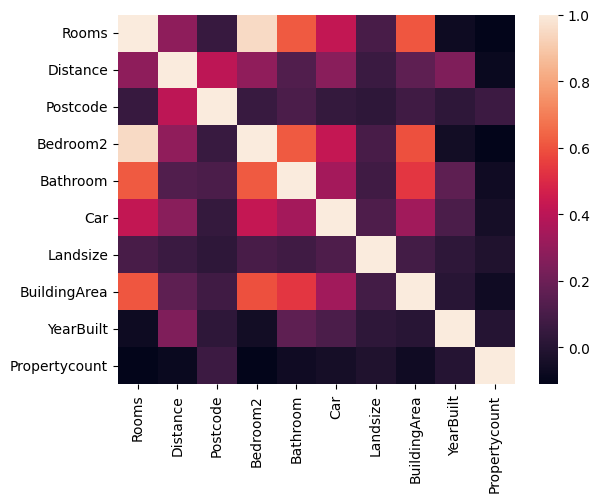

In [ ]:
corr = dataset[features].corr()
sns.heatmap(corr);

Lembrem-se, se você tiver uma coluna categórica nas features, precisa fazer OneHotEncoding / LabelEncoding!


In [94]:
dataset2 = pd.read_csv(path+ '50_Startups.csv')

dataset2.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


A classe selecionada **já trata** do caso das variáveis dummy! Não precisa eliminar uma coluna.

Assim como, essa classe já encontra as melhores features -> dá coeficientes mais baixos para as features que não tem um p tão bom.

In [98]:
dataset2.shape

(50, 5)

In [99]:
X = dataset2.iloc[:, :-1].values
y = dataset2.iloc[:, -1].values

X

array([[165349.2, 136897.8, 471784.1, 'New York'],
       [162597.7, 151377.59, 443898.53, 'California'],
       [153441.51, 101145.55, 407934.54, 'Florida'],
       [144372.41, 118671.85, 383199.62, 'New York'],
       [142107.34, 91391.77, 366168.42, 'Florida'],
       [131876.9, 99814.71, 362861.36, 'New York'],
       [134615.46, 147198.87, 127716.82, 'California'],
       [130298.13, 145530.06, 323876.68, 'Florida'],
       [120542.52, 148718.95, 311613.29, 'New York'],
       [123334.88, 108679.17, 304981.62, 'California'],
       [101913.08, 110594.11, 229160.95, 'Florida'],
       [100671.96, 91790.61, 249744.55, 'California'],
       [93863.75, 127320.38, 249839.44, 'Florida'],
       [91992.39, 135495.07, 252664.93, 'California'],
       [119943.24, 156547.42, 256512.92, 'Florida'],
       [114523.61, 122616.84, 261776.23, 'New York'],
       [78013.11, 121597.55, 264346.06, 'California'],
       [94657.16, 145077.58, 282574.31, 'New York'],
       [91749.16, 114175.79, 29491

In [100]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [3])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

X

array([[0.0, 0.0, 1.0, 165349.2, 136897.8, 471784.1],
       [1.0, 0.0, 0.0, 162597.7, 151377.59, 443898.53],
       [0.0, 1.0, 0.0, 153441.51, 101145.55, 407934.54],
       [0.0, 0.0, 1.0, 144372.41, 118671.85, 383199.62],
       [0.0, 1.0, 0.0, 142107.34, 91391.77, 366168.42],
       [0.0, 0.0, 1.0, 131876.9, 99814.71, 362861.36],
       [1.0, 0.0, 0.0, 134615.46, 147198.87, 127716.82],
       [0.0, 1.0, 0.0, 130298.13, 145530.06, 323876.68],
       [0.0, 0.0, 1.0, 120542.52, 148718.95, 311613.29],
       [1.0, 0.0, 0.0, 123334.88, 108679.17, 304981.62],
       [0.0, 1.0, 0.0, 101913.08, 110594.11, 229160.95],
       [1.0, 0.0, 0.0, 100671.96, 91790.61, 249744.55],
       [0.0, 1.0, 0.0, 93863.75, 127320.38, 249839.44],
       [1.0, 0.0, 0.0, 91992.39, 135495.07, 252664.93],
       [0.0, 1.0, 0.0, 119943.24, 156547.42, 256512.92],
       [0.0, 0.0, 1.0, 114523.61, 122616.84, 261776.23],
       [1.0, 0.0, 0.0, 78013.11, 121597.55, 264346.06],
       [0.0, 0.0, 1.0, 94657.16, 145077.58

##

In [111]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)


In [112]:
mean_absolute_error(y_test, y_pred)

7514.29365964318

In [ ]:
y

array([192261.83, 191792.06, 191050.39, 182901.99, 166187.94, 156991.12,
       156122.51, 155752.6 , 152211.77, 149759.96, 146121.95, 144259.4 ,
       141585.52, 134307.35, 132602.65, 129917.04, 126992.93, 125370.37,
       124266.9 , 122776.86, 118474.03, 111313.02, 110352.25, 108733.99,
       108552.04, 107404.34, 105733.54, 105008.31, 103282.38, 101004.64,
        99937.59,  97483.56,  97427.84,  96778.92,  96712.8 ,  96479.51,
        90708.19,  89949.14,  81229.06,  81005.76,  78239.91,  77798.83,
        71498.49,  69758.98,  65200.33,  64926.08,  49490.75,  42559.73,
        35673.41,  14681.4 ])

In [113]:
y.mean()

np.float64(112012.63920000002)

In [114]:
y_pred

array([103015.2 , 132582.28, 132447.74,  71976.1 , 178537.48, 116161.24,
        67851.69,  98791.73, 113969.44, 167921.07])

In [115]:
np.set_printoptions(precision=2)
print(np.concatenate(( y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1) ) ,1 ))
#Concatena em duas colunas y previsto e y real

[[103015.2  103282.38]
 [132582.28 144259.4 ]
 [132447.74 146121.95]
 [ 71976.1   77798.83]
 [178537.48 191050.39]
 [116161.24 105008.31]
 [ 67851.69  81229.06]
 [ 98791.73  97483.56]
 [113969.44 110352.25]
 [167921.07 166187.94]]


#Regressão linear **polinomial**

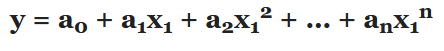

In [118]:
dataset = pd.read_csv(path+ 'Position_Salaries.csv')
dataset

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [119]:
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

In [120]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)

LinearRegression()

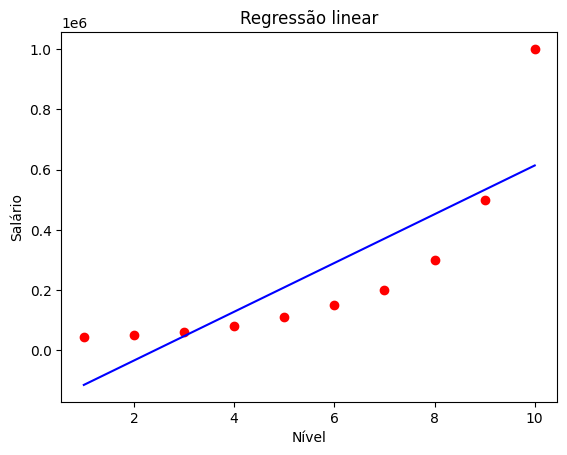

In [121]:
plt.scatter(X, y, color = 'red')
plt.plot(X, lin_reg.predict(X), color = 'blue')
plt.title('Regressão linear')
plt.xlabel('Nível')
plt.ylabel('Salário')
plt.show()

In [ ]:
mean_absolute_error(y, lin_reg.predict(X))

128454.54545454546

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree = 5) #testar 2, 3, 4, 5
X_poly = poly_reg.fit_transform(X) #criou nova matriz X, em que x^2 (x^3... x^4... x^5...) entra como uma nova feature!

X_poly

array([[1.00e+00, 1.00e+00, 1.00e+00, 1.00e+00, 1.00e+00, 1.00e+00],
       [1.00e+00, 2.00e+00, 4.00e+00, 8.00e+00, 1.60e+01, 3.20e+01],
       [1.00e+00, 3.00e+00, 9.00e+00, 2.70e+01, 8.10e+01, 2.43e+02],
       [1.00e+00, 4.00e+00, 1.60e+01, 6.40e+01, 2.56e+02, 1.02e+03],
       [1.00e+00, 5.00e+00, 2.50e+01, 1.25e+02, 6.25e+02, 3.12e+03],
       [1.00e+00, 6.00e+00, 3.60e+01, 2.16e+02, 1.30e+03, 7.78e+03],
       [1.00e+00, 7.00e+00, 4.90e+01, 3.43e+02, 2.40e+03, 1.68e+04],
       [1.00e+00, 8.00e+00, 6.40e+01, 5.12e+02, 4.10e+03, 3.28e+04],
       [1.00e+00, 9.00e+00, 8.10e+01, 7.29e+02, 6.56e+03, 5.90e+04],
       [1.00e+00, 1.00e+01, 1.00e+02, 1.00e+03, 1.00e+04, 1.00e+05]])

In [122]:
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly, y)

LinearRegression()

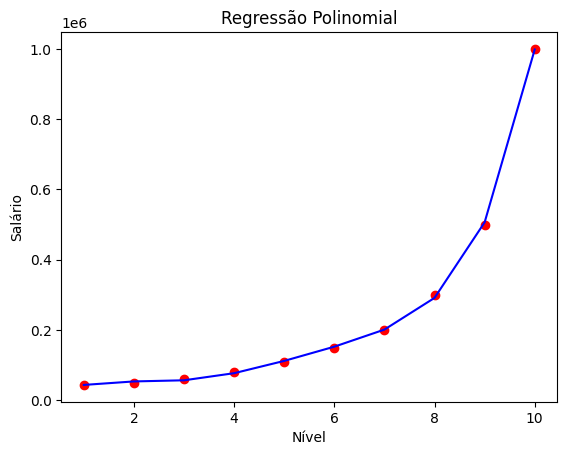

In [123]:
plt.scatter(X, y, color = 'red')
plt.plot(X, lin_reg_2.predict(X_poly), color = 'blue')
plt.title('Regressão Polinomial')
plt.xlabel('Nível')
plt.ylabel('Salário')
plt.show()

In [124]:
mean_absolute_error(y, lin_reg_2.predict(X_poly))

3360.83916091242

/tmp/ipykernel_1634/3061864919.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1)


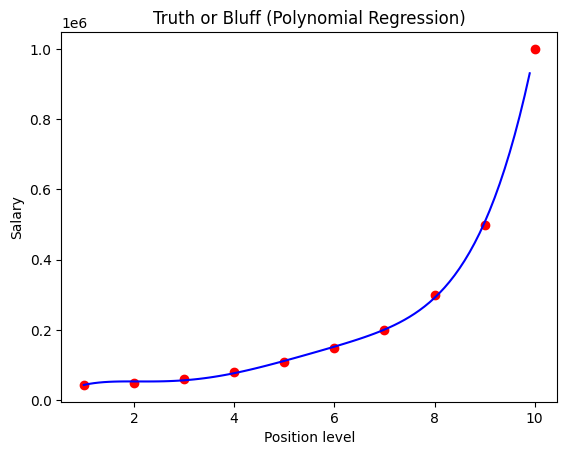

In [125]:
X_grid = np.arange(min(X), max(X), 0.1)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X, y, color = 'red')
plt.plot(X_grid, lin_reg_2.predict(poly_reg.fit_transform(X_grid)), color = 'blue')
plt.title('Truth or Bluff (Polynomial Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

In [126]:
lin_reg_2.predict(poly_reg.fit_transform([[6.5]]))

array([174878.08])